# Clase 6 · Inferencia estadística y regresión logística

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

**Qué hacemos hoy.** Dos partes. En la primera, lo que quedó pendiente de la clase 04: la pendiente de −4,8 minutos por millón, calculada con 45 comunas, ¿es real o es azar? Reconstruimos la recta, la movemos con el bootstrap y leemos completo el summary de statsmodels: error estándar, intervalo, t y valor p. En la segunda, una respuesta que es sí o no: la regresión logística con los 10.000 clientes de tarjeta de crédito del libro de James et al. y los 891 pasajeros del Titanic, y cómo clasificar con ella.

**Las dos ideas de la clase.** Primera: todo número que sale de una muestra se mueve, y el error estándar mide cuánto. Segunda: la regresión logística no predice el sí o el no, predice una probabilidad; la decisión, y sus dos errores, la ponemos nosotros.


## 1. Preparación

Los datos de siempre: viajes y hogares de la EOD, y la tabla por comuna de la clase 04, ponderada por el factor, con su recta.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
# scipy.stats: las distribuciones de probabilidad con nombre
from scipy import stats

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
# Datos locales del repositorio clonado (se corre desde la raíz del repositorio)
BASE = "datos/eod_stgo/"
# Alternativa por URL, si no tiene el repositorio clonado:
# BASE = "https://raw.githubusercontent.com/daniopitz/cienciadatos/main/datos/eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

# La población de hoy: la duración de cada viaje, sin faltantes ni ceros
duracion = viajes["TiempoViaje"].dropna()
duracion = duracion[duracion > 0]
len(duracion)

113113

In [4]:
# La tabla por comuna de la clase 04: medias ponderadas por el factor
viajes_final = viajes.merge(
    hogares[["Hogar", "Comuna", "IngresoHogar", "NumVeh", "NumPer"]], on="Hogar")
viajes_final = viajes_final.dropna(
    subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()

w = viajes_final["FactorLaboralNormal"]
for col in ["IngresoHogar", "TiempoViaje"]:
    viajes_final["w_" + col] = w * viajes_final[col]

suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
por_comuna = pd.DataFrame({
    "ingreso": suma["w_IngresoHogar"] / suma["FactorLaboralNormal"],
    "duracion": suma["w_TiempoViaje"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)
por_comuna.head()

,Comuna,ingreso,duracion,n
0,BUIN,611584.779504,27.767868,889
1,CALERA DE TANGO,609311.812531,39.746297,629
2,CERRILLOS,578682.733281,34.824237,760
3,CERRO NAVIA,457758.557018,36.010691,1113
4,COLINA,636524.561820,32.607995,1177


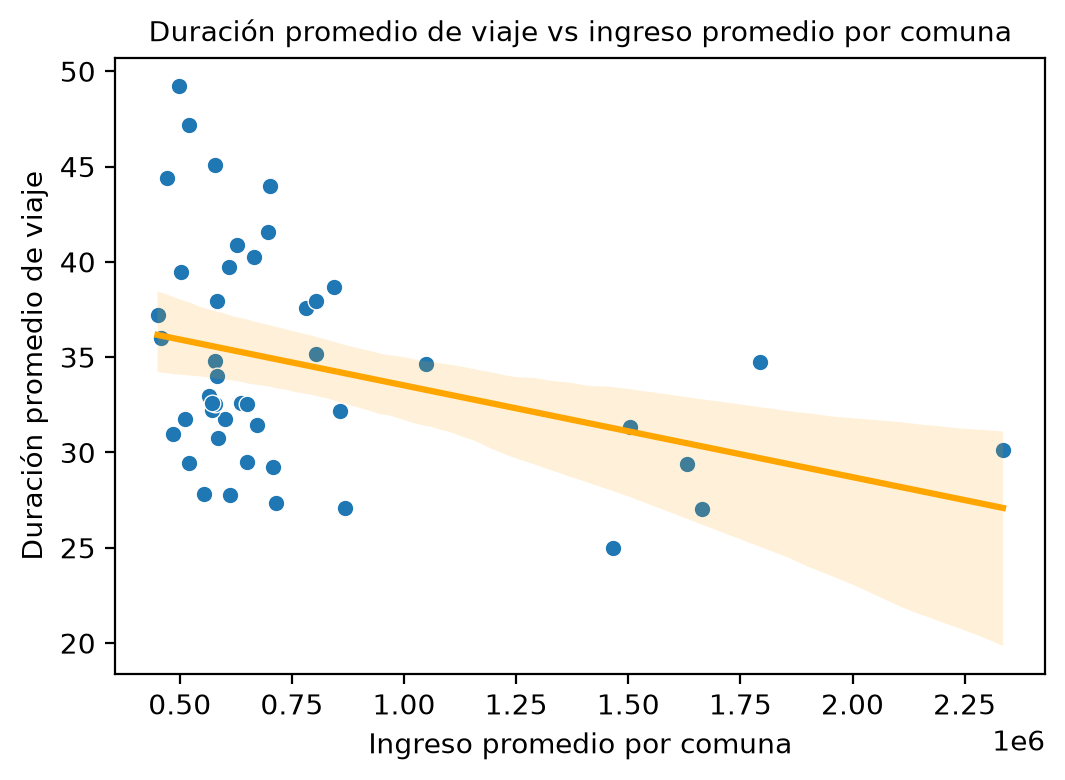

In [5]:
#grafico de dispersión de ingreso vs duración, con la línea de regresión
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=por_comuna, x="ingreso", y="duracion", ax=ax)
sns.regplot(
    data=por_comuna, x="ingreso", y="duracion", ax=ax, scatter=False, color="orange")
ax.set_xlabel("Ingreso promedio por comuna")
ax.set_ylabel("Duración promedio de viaje")
ax.set_title("Duración promedio de viaje vs ingreso promedio por comuna", size=10)
plt.show()  

### La recta de la clase 04, con statsmodels: OLS

**OLS** (ordinary least squares, mínimos cuadrados ordinarios) ajusta la recta y devuelve un objeto con todo lo que necesitamos: `.params` son los coeficientes, `.predict(X)` calcula la predicción para las filas de `X`, `.resid` los residuos, y `.summary().tables[1]` la tabla de coeficientes que leeremos completa en la sección 2 y en las slides.

**La constante.** OLS ajusta un coeficiente por cada columna de `X`, y nada más: con solo la columna ingreso, la recta pasaría obligada por el origen. Para que tenga intercepto se le agrega una columna llena de unos, `const`, con `sm.add_constant`; el modelo queda duración = a · 1 + b · ingreso, y a es el coeficiente de esa columna. Por eso `.params` trae dos números: const es el intercepto e ingreso es la pendiente.

In [6]:
X = sm.add_constant(por_comuna["ingreso"] / 1e6)   # el ingreso en millones, más la constante
modelo_c = sm.OLS(por_comuna["duracion"], X).fit()
intercepto, pendiente = modelo_c.params   # const e ingreso
print(modelo_c.params.round(2))

const      38.34
ingreso    -4.81
dtype: float64


La recta es duración = 38,3 − 4,8 · ingreso. Las predicciones y los residuos salen del modelo ajustado; la predicción es también el intercepto más la pendiente por el ingreso, que se puede verificar a mano:

In [7]:
por_comuna["prediccion"] = modelo_c.predict(X)        # lo mismo que modelo_c.fittedvalues
por_comuna["residuo"] = modelo_c.resid                 # observado menos predicho
por_comuna["a_mano"] = intercepto + pendiente * por_comuna["ingreso"] / 1e6
por_comuna[["Comuna", "ingreso", "duracion", "prediccion", "a_mano", "residuo"]].head()

,Comuna,ingreso,duracion,prediccion,a_mano,residuo
0,BUIN,611584.779504,27.767868,35.390729,35.390729,-7.622861
1,CALERA DE TANGO,609311.812531,39.746297,35.401672,35.401672,4.344625
2,CERRILLOS,578682.733281,34.824237,35.549138,35.549138,-0.724901
3,CERRO NAVIA,457758.557018,36.010691,36.131335,36.131335,-0.120645
4,COLINA,636524.561820,32.607995,35.270655,35.270655,-2.662659


Para predecir en una comuna que no hemos visto la recta se escribe como texto, `duracion ~ ingreso_m` (la respuesta a la izquierda de `~`, las variables a la derecha), el intercepto va incluido sin columnas de unos, y `predict` recibe una tabla con solo el ingreso de la comuna nueva:

In [8]:
import statsmodels.formula.api as smf

por_comuna["ingreso_m"] = por_comuna["ingreso"] / 1e6   # el ingreso en millones, con nombre propio
modelo_f = smf.ols("duracion ~ ingreso_m", data=por_comuna).fit()
print(modelo_f.params.round(2))   # Intercept es a; ingreso_m es b

Intercept    38.34
ingreso_m    -4.81
dtype: float64


In [9]:
# Una comuna que no hemos visto, con ingreso medio de 1,5 millones
nueva = pd.DataFrame({"Comuna": ["Nueva Comuna"], "ingreso_m": [1.5]})
nueva["prediccion"] = modelo_f.predict(nueva)
nueva

,Comuna,ingreso_m,prediccion
0,Nueva Comuna,1.5,31.113395


In [10]:
# Lo mismo a mano, con el intercepto y la pendiente que guarda el modelo
a, b = modelo_f.params["Intercept"], modelo_f.params["ingreso_m"]
print(f"{a:.2f} + ({b:.2f}) · 1,5 = {a + b * 1.5:.1f} min")

38.34 + (-4.81) · 1,5 = 31.1 min


In [11]:
print("R²:", round(modelo_f.rsquared, 3))

R²: 0.117


In [12]:
modelo_c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duracion   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     5.707
Date:                Fri, 02 Oct 2026   Prob (F-statistic):             0.0214
Time:                        14:17:58   Log-Likelihood:                -139.50
No. Observations:                  45   AIC:                             283.0
Df Residuals:                      43   BIC:                             286.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.3352      1.773     21.622      0.000      34.760      41.911
ingreso       -4.8146      2.015     -2.389      0.021      -8.879      -0.750
==============================================================================
Omnibus:                        2.948   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.229   Jarque-Bera (JB):                2.776
Skew:                           0.556   Prob(JB):                        0.250
Kurtosis:                       2.504   Cond. No.                         4.12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
# La tabla de coeficientes, que hoy leeremos completa
modelo_c.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


## 2. La pendiente también se mueve: bootstrap

**Objetivo:** medir cuánto se movería la pendiente de las comunas con otra muestra, y comparar ese número con el error estándar que statsmodels imprime.

La pendiente de −4,8 minutos por millón salió de estas 45 comunas; con otras 45, los puntos y la recta serían otros. Como no hay otra muestra de comunas, el **bootstrap** usa la que tenemos como si fuera la población: saca 45 comunas **con reemplazo** (cada comuna vuelve a la bolsa antes de sacar la siguiente, así que puede repetirse y otra puede no salir), ajusta la recta y guarda la pendiente. Repetido muchas veces, da la distribución de la pendiente. La explicación completa está en las slides; aquí, cómo se hace.

In [14]:
x = por_comuna["ingreso"].values / 1e6   # el ingreso, en millones
y = por_comuna["duracion"].values


def pendiente_ols(x, y):
    """La pendiente de la recta de mínimos cuadrados de y sobre x, con OLS."""
    return sm.OLS(y, sm.add_constant(x)).fit().params[1]


a_observada, b_observada = sm.OLS(y, sm.add_constant(x)).fit().params
print(f"pendiente observada: {b_observada:.2f} min por millón")

pendiente observada: -4.81 min por millón


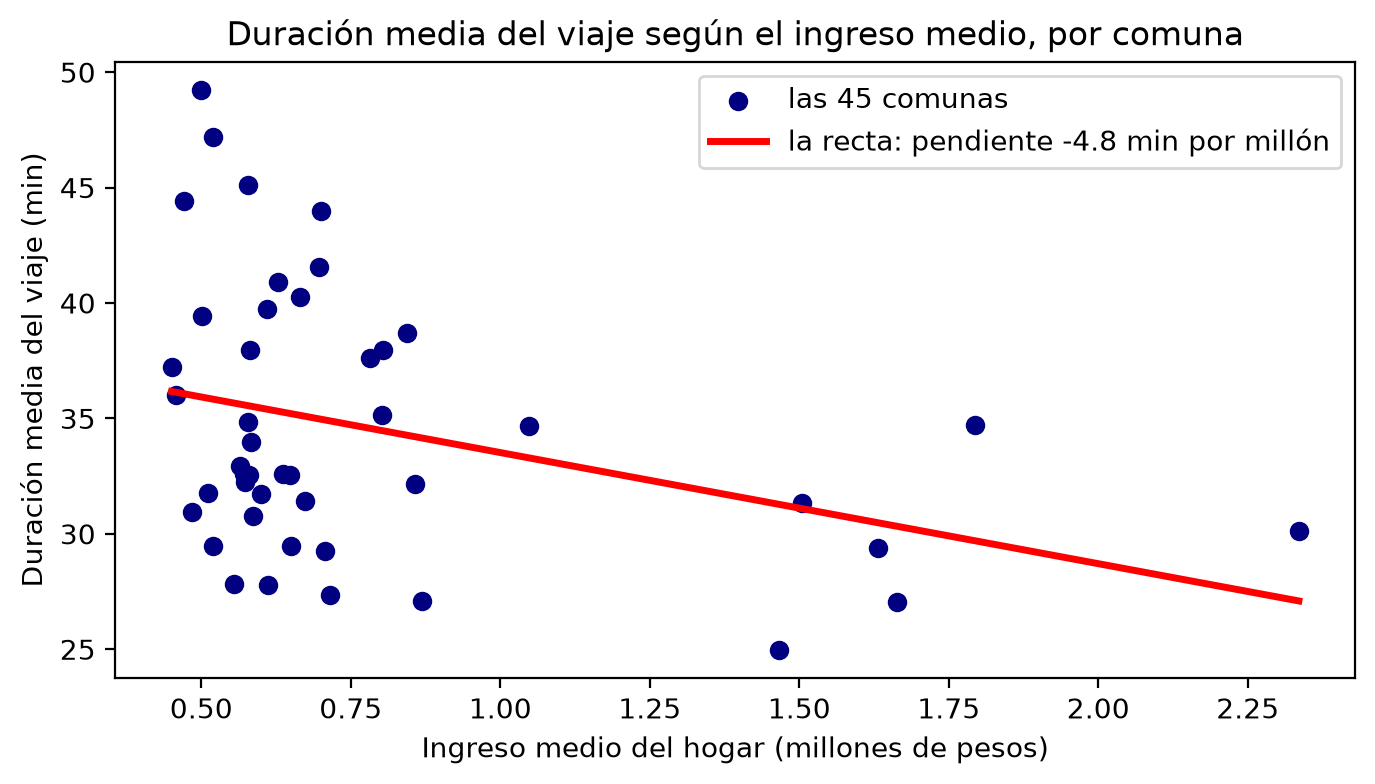

In [15]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, color="navy", label="las 45 comunas")
grilla = np.linspace(x.min(), x.max(), 50)
ax.plot(grilla, a_observada + b_observada * grilla, color="red", lw=2.5,
        label=f"la recta: pendiente {b_observada:.1f} min por millón")
ax.set(xlabel="Ingreso medio del hogar (millones de pesos)", ylabel="Duración media del viaje (min)",
       title="Duración media del viaje según el ingreso medio, por comuna")
ax.legend()
plt.show()

**Una remuestra.** `resample` de scikit-learn saca filas al azar con reemplazo. Recibe tres arreglos del mismo largo, uno por columna de la tabla de comunas, y devuelve tres arreglos nuevos del mismo largo con las filas que salieron:

- `comunas`, `x`, `y`: las 45 comunas, sus ingresos medios (en millones) y sus duraciones medias. La fila k de los tres es la misma comuna.
- `comunas_r`, `x_r`, `y_r`: la remuestra. Los nombres de las 45 comunas que salieron, con su ingreso y su duración, también en el mismo orden.

Como es con reemplazo, una comuna puede salir varias veces y otra ninguna. `random_state` fija la semilla para que la remuestra sea la misma cada vez que se corre el notebook.

In [16]:
from sklearn.utils import resample

comunas = por_comuna["Comuna"].values
comunas_r, x_r, y_r = resample(comunas, x, y, replace=True, random_state=42)
print(list(comunas_r[:8]))   # las primeras 8 comunas de la remuestra

veces = pd.Series(comunas_r).value_counts()   # cuántas veces salió cada comuna
print(f"comunas distintas: {len(veces)} | no salieron: {len(comunas) - len(veces)} | salieron dos o más veces: {(veces >= 2).sum()}")
print(f"pendiente observada: {b_observada:.2f} | pendiente de esta remuestra: {pendiente_ols(x_r, y_r):.2f}")
veces.head(5)

['SAN JOAQUIN', 'PEÑALOLEN', 'LA GRANJA', 'TALAGANTE', 'EL MONTE', 'LO ESPEJO', 'SAN JOAQUIN', 'LAS CONDES']
comunas distintas: 31 | no salieron: 14 | salieron dos o más veces: 10
pendiente observada: -4.81 | pendiente de esta remuestra: -6.92


SAN JOAQUIN    3
LO ESPEJO      3
MAIPU          3
VITACURA       3
LA GRANJA      2
Name: count, dtype: int64

**El ciclo.** Una función que repite eso `B` veces y devuelve las `B` pendientes. La semilla fija el resultado de cada corrida:

In [17]:
def pendientes_bootstrap(B, semilla):
    """B remuestras de las 45 comunas, con reemplazo, y la pendiente OLS de cada una."""
    rng = np.random.default_rng(semilla)
    pendientes = []
    for _ in range(B):
        x_r, y_r = resample(x, y, replace=True, random_state=rng.integers(1_000_000))
        pendientes.append(pendiente_ols(x_r, y_r))
    return np.array(pendientes)


pendientes_bootstrap(5, semilla=1).round(2)

array([-5.07, -4.34, -4.96, -4.33, -5.78])

Cinco remuestras, cinco pendientes distintas. La desviación estándar de las pendientes es el **error estándar bootstrap**: cuánto se mueve la pendiente de una muestra a otra. ¿Y cuántas remuestras hacen falta para medirlo bien?

**Pocas contra muchas.** Se calcula el error estándar con B = 10, 30, 100, 300, 1.000, 2.000 y 5.000 remuestras, y cada cálculo se repite cinco veces con semillas distintas. Si el error estándar cambia de una corrida a otra, B es poco; cuando deja de cambiar, ya alcanza:

In [18]:
Bs = [10, 30, 100, 300, 1000, 2000, 5000]
corridas = pd.DataFrame({f"corrida {k + 1}": [pendientes_bootstrap(B, semilla=k).std() for B in Bs]
                         for k in range(5)}, index=pd.Index(Bs, name="B remuestras"))
corridas["rango"] = corridas.max(axis=1) - corridas.min(axis=1)
corridas.round(2)

,corrida 1,corrida 2,corrida 3,corrida 4,corrida 5,rango
B remuestras,,,,,,
10,0.97,0.95,1.12,1.37,1.42,0.47
30,2.10,1.27,1.09,1.60,1.75,1.01
100,2.07,1.74,1.85,1.56,1.82,0.51
300,1.92,1.82,1.84,1.55,1.76,0.37
1000,1.81,1.87,1.76,1.72,1.80,0.15
2000,1.77,1.87,1.81,1.73,1.80,0.15
5000,1.82,1.85,1.80,1.78,1.82,0.07


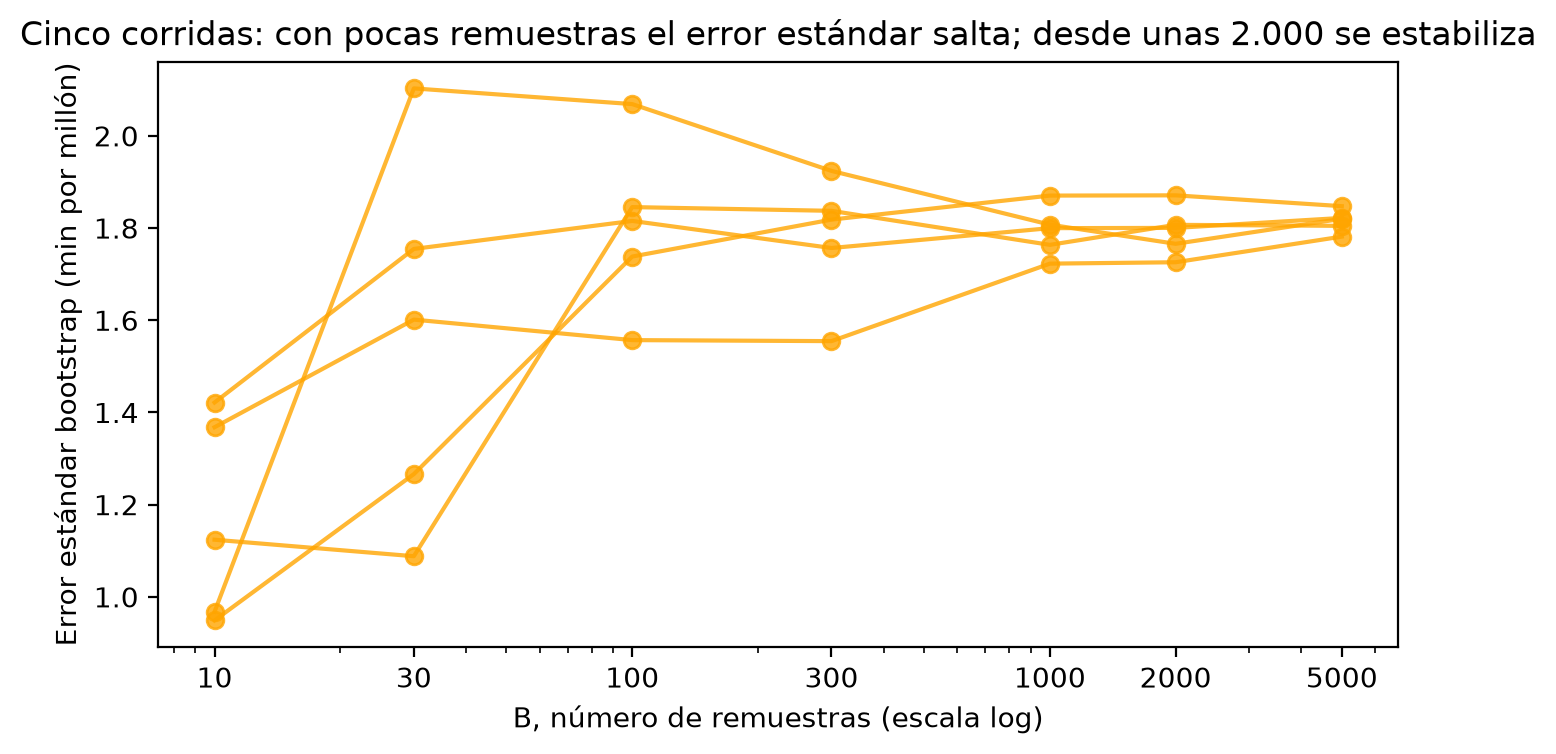

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for col in corridas.columns[:-1]:
    ax.plot(Bs, corridas[col], marker="o", color="orange", alpha=0.8)
ax.set_xscale("log")
ax.set(xlabel="B, número de remuestras (escala log)", ylabel="Error estándar bootstrap (min por millón)",
       title="Cinco corridas: con pocas remuestras el error estándar salta; desde unas 2.000 se estabiliza")
ax.set_xticks(Bs); ax.set_xticklabels(Bs)
plt.show()

Con 10 o 30 remuestras las cinco corridas dan errores estándar distintos: el rango entre corridas llega a 1 minuto por millón, la mitad del valor que se quiere medir. Con 1.000 o más remuestras el rango baja a 0,15 y las cinco corridas dicen lo mismo. El histograma muestra lo mismo: tosco con 30, una campana con 2.000.

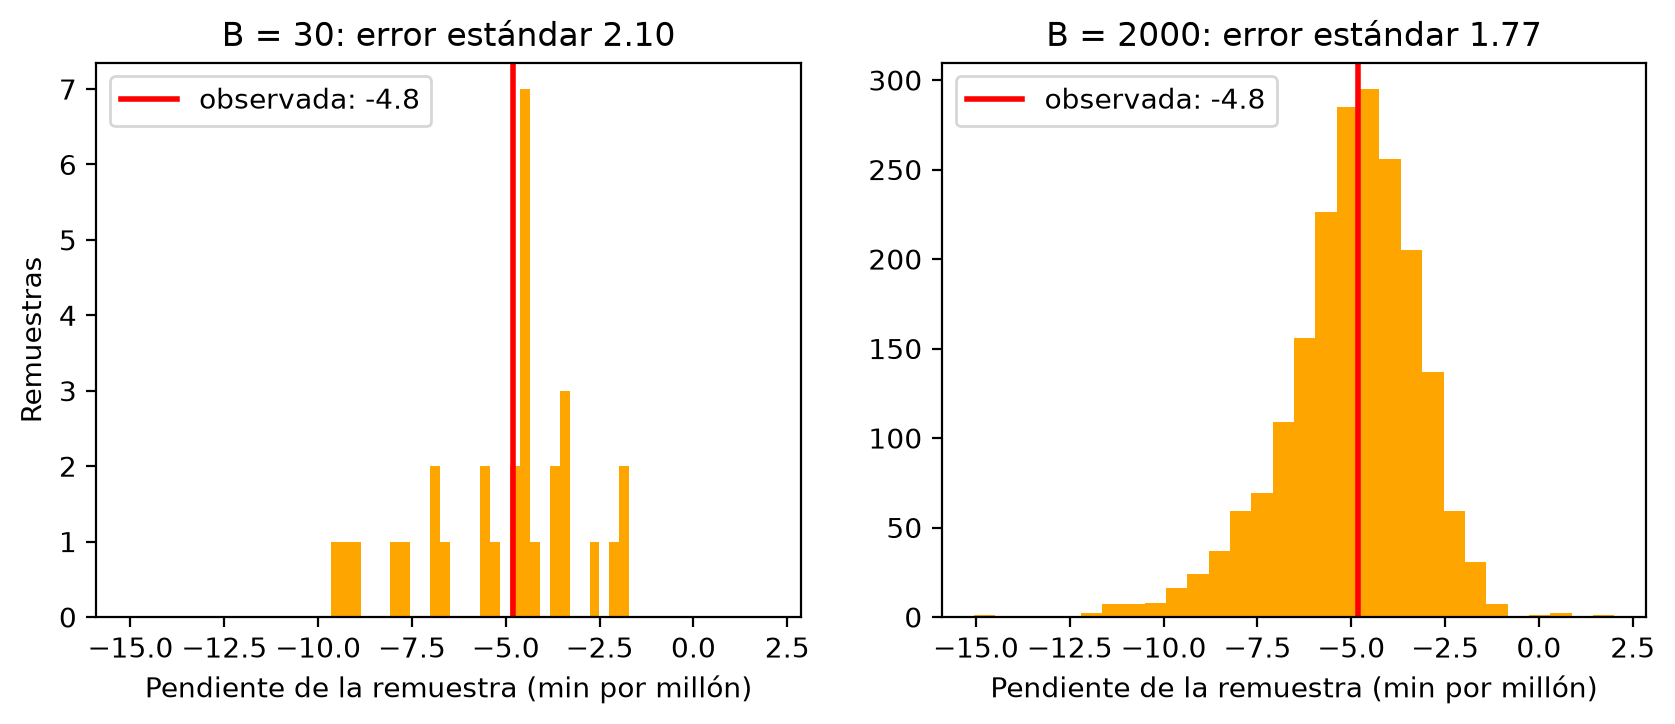

In [20]:
pocas = pendientes_bootstrap(30, semilla=0)
muchas = pendientes_bootstrap(2000, semilla=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, pend, B in zip(axes, [pocas, muchas], [30, 2000]):
    ax.hist(pend, bins=30, color="orange")
    ax.axvline(b_observada, color="red", lw=2, label=f"observada: {b_observada:.1f}")
    ax.set(title=f"B = {B}: error estándar {pend.std():.2f}", xlabel="Pendiente de la remuestra (min por millón)")
    ax.legend()
axes[0].set_ylabel("Remuestras")
plt.show()

**El intervalo bootstrap.** Con las 2.000 pendientes ordenadas, los percentiles 2,5 y 97,5 dejan al centro el 95% de las remuestras: ese es el intervalo de confianza del 95%, leído directo del histograma, sin suponer forma de campana:

In [21]:
pendientes = muchas
inferior, superior = np.percentile(pendientes, [2.5, 97.5])
print(f"error estándar bootstrap: {pendientes.std():.2f}")
print(f"intervalo bootstrap 95%: [{inferior:.2f}, {superior:.2f}]")

error estándar bootstrap: 1.77
intervalo bootstrap 95%: [-9.20, -2.03]


**Comparación con la fórmula.** statsmodels calcula el error estándar de la pendiente sin remuestrear, a partir de los residuos (la fórmula está en las slides): es la columna **std err** del summary, y el intervalo son las columnas **[0.025, 0.975]**. `modelo.bse` y `modelo.conf_int()` devuelven esos mismos números:

In [22]:
modelo = sm.OLS(por_comuna["duracion"], sm.add_constant(por_comuna["ingreso"] / 1e6)).fit()
ee_formula = modelo.bse["ingreso"]
intervalo_formula = modelo.conf_int().loc["ingreso"]

pd.DataFrame({
    "sin bootstrap (fórmula)": [round(b_observada, 2), round(ee_formula, 2),
                               f"[{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]"],
    "con bootstrap (2.000 remuestras)": [round(b_observada, 2), round(pendientes.std(), 2),
                                        f"[{inferior:.2f}, {superior:.2f}]"],
}, index=["pendiente", "error estándar", "intervalo 95%"])

,sin bootstrap (fórmula),con bootstrap (2.000 remuestras)
pendiente,-4.81,-4.81
error estándar,2.02,1.77
intervalo 95%,"[-8.88, -0.75]","[-9.20, -2.03]"


Se parecen, y ninguno incluye el 0. La fila *pendiente* es la misma en las dos columnas, y así debe ser: el bootstrap no cambia la pendiente, cambia cuánto le creemos. La fórmula es instantánea pero supone cosas sobre los residuos; el bootstrap sirve para cualquier estadístico (una mediana, una razón, la métrica de un modelo) y no supone forma de campana.

### Lo mismo con scipy

`scipy.stats.bootstrap` hace el ciclo completo por nosotros: recibe los datos, el estadístico y el número de remuestras, y devuelve el intervalo y el error estándar. Como la pendiente necesita el ingreso y la duración de la misma comuna, se le pasan las dos variables juntas con `paired=True`, para que remuestree filas y no cada columna por separado:

In [23]:
from scipy.stats import bootstrap

res = bootstrap((x, y), pendiente_ols, paired=True, n_resamples=2000, random_state=42)
print(f"intervalo bootstrap 95% (scipy): [{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}]")
print(f"error estándar bootstrap (scipy): {res.standard_error:.2f}")
print(f"error estándar bootstrap (nuestro ciclo): {pendientes.std():.2f} | fórmula de statsmodels: {ee_formula:.2f}")

intervalo bootstrap 95% (scipy): [-9.10, -1.88]
error estándar bootstrap (scipy): 1.90
error estándar bootstrap (nuestro ciclo): 1.77 | fórmula de statsmodels: 2.02


Tres caminos, el mismo número. El ciclo con `resample` muestra qué hace el bootstrap; `scipy.stats.bootstrap` lo hace en una línea; la fórmula de statsmodels no remuestrea nada. Cuando los tres coinciden, la fórmula está bien.

## Segunda parte · Regresión logística: ¿sí o no?

Modelar una respuesta que es sí o no. Primero con los 10.000 clientes de tarjeta de crédito del libro de James et al.: la regresión logística, cómo se lee e^b y el mismo summary de siempre. Después con varias variables, en los clientes y en los 891 pasajeros del Titanic. Y al final, clasificar: el umbral, la matriz de confusión, los falsos positivos y falsos negativos, y evaluar el modelo en datos que no vio. Sensibilidad, especificidad y cómo elegir el umbral quedan para la clase de evaluación de modelos.

**El hilo de esta parte:** el modelo no predice el sí o el no, predice una probabilidad. La decisión, y sus dos errores, la ponemos nosotros.


## 3. Preparación

Las mismas bibliotecas de la primera parte. `smf`, la API de fórmulas de statsmodels, ya apareció en la sección 1 con `smf.ols`; aquí usamos `smf.logit`.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [25]:
# Datos locales del repositorio clonado
BASE = "datos/clase06/"
# Alternativa por URL, si no tiene el repositorio clonado:
# BASE = "https://raw.githubusercontent.com/daniopitz/cienciadatos/main/datos/clase06/"

**Los datos del ejemplo 1.** `Default.csv` viene con el libro *An Introduction to Statistical Learning* (James, Witten, Hastie y Tibshirani): 10.000 clientes de una tarjeta de crédito, con su deuda en la tarjeta (`balance`: lo que deben después del pago mensual, en dólares), su ingreso anual (`income`) y si son estudiantes. La respuesta es `default`: si dejaron de pagar. Creamos las columnas en español y en escalas cómodas: la deuda en cientos de dólares y el ingreso en miles.

In [26]:
clientes = pd.read_csv(BASE + "default_islr.csv")
clientes["no_paga"] = (clientes["default"] == "Yes").astype(int)   # la respuesta: 1 si dejó de pagar
clientes["estudiante"] = (clientes["student"] == "Yes").astype(int)
clientes["deuda_100"] = clientes["balance"] / 100      # la deuda, en cientos de dólares
clientes["ingreso_miles"] = clientes["income"] / 1000  # el ingreso anual, en miles de dólares
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles
0,No,No,729.526,44361.625,0,0,7.295,44.362
1,No,Yes,817.180,12106.135,0,1,8.172,12.106
2,No,No,1073.549,31767.139,0,0,10.735,31.767
3,No,No,529.251,35704.494,0,0,5.293,35.704
4,No,No,785.656,38463.496,0,0,7.857,38.463


## 4. Una respuesta que es sí o no

**Objetivo:** ver qué es una variable 0/1 y qué la resume.

La respuesta `no_paga` vale 1 o 0. La media de una columna de 0 y 1 es la fracción de unos: la **proporción** de clientes que dejaron de pagar. Un cliente tomado al azar es una **Bernoulli** con esa probabilidad $p$: la distribución más simple, dos resultados y una probabilidad.

In [27]:
n_clientes = len(clientes)
print(f"Total de clientes: {n_clientes}")

Total de clientes: 10000


In [28]:
n_no_pagan = clientes["no_paga"].sum()   # sumar la columna cuenta los unos
print(f"Clientes que pagan: {n_clientes - n_no_pagan} ({(n_clientes - n_no_pagan)/n_clientes:.1%})")
print(f"Clientes que no pagan: {n_no_pagan} ({n_no_pagan/n_clientes:.1%})")

Clientes que pagan: 9667 (96.7%)
Clientes que no pagan: 333 (3.3%)


## 5. La probabilidad de no pagar, por tramo de deuda

**Objetivo:** estimar la probabilidad de no pagar según la deuda, directo de los datos.

Lo que queremos es que $p$ dependa de $x$: que la probabilidad de no pagar cambie con la deuda. Antes de ajustar nada, qué forma tienen los datos. Se agrupan los clientes por **tramo** de deuda, un intervalo de 300 dólares (0 a 300, 300 a 600, y así hasta 2.700: nueve tramos), y en cada tramo se cuenta cuántos clientes hay y cuántos dejaron de pagar. La fracción es la probabilidad de no pagar de ese tramo, estimada con los datos:

In [29]:
clientes["balance"].describe()

count   10000.000
mean      835.375
std       483.715
min         0.000
25%       481.731
50%       823.637
75%      1166.308
max      2654.323
Name: balance, dtype: float64

In [30]:
# pd.cut agrupa la deuda en tramos de 300 dólares; en cada tramo se cuenta cuántos clientes hay y cuántos no pagan
clientes["tramo"] = pd.cut(clientes["balance"], np.arange(0, 2701, 300))
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles,tramo
0,No,No,729.526,44361.625,0,0,7.295,44.362,"(600, 900]"
1,No,Yes,817.180,12106.135,0,1,8.172,12.106,"(600, 900]"
2,No,No,1073.549,31767.139,0,0,10.735,31.767,"(900, 1200]"
3,No,No,529.251,35704.494,0,0,5.293,35.704,"(300, 600]"
4,No,No,785.656,38463.496,0,0,7.857,38.463,"(600, 900]"


In [31]:
grupos = clientes.groupby("tramo")   # un grupo por tramo

por_tramo = pd.DataFrame()
por_tramo["clientes"] = grupos.size()                 # cuántos clientes hay en el tramo
por_tramo["no_pagan"] = grupos["no_paga"].sum()       # cuántos tienen un 1
por_tramo["Deuda"] = grupos["balance"].mean()         # deuda media del tramo, para el gráfico
por_tramo.head()

,clientes,no_pagan,Deuda
tramo,,,
"(0, 300]",998,0,168.815
"(300, 600]",1784,0,458.584
"(600, 900]",2308,3,751.196
"(900, 1200]",2117,19,1041.429
"(1200, 1500]",1383,53,1333.344


In [32]:
por_tramo["Fraccion"] = por_tramo["no_pagan"] / por_tramo["clientes"]   # la fracción que no paga: la probabilidad estimada en el tramo
por_tramo

,clientes,no_pagan,Deuda,Fraccion
tramo,,,,
"(0, 300]",998,0,168.815,0.000
"(300, 600]",1784,0,458.584,0.000
"(600, 900]",2308,3,751.196,0.001
"(900, 1200]",2117,19,1041.429,0.009
"(1200, 1500]",1383,53,1333.344,0.038
"(1500, 1800]",623,96,1627.923,0.154
"(1800, 2100]",229,114,1913.010,0.498
"(2100, 2400]",52,41,2209.210,0.788
"(2400, 2700]",7,7,2503.520,1.000


Cada fila es un cálculo simple: entre 1.800 y 2.100 dólares hay 229 clientes y 114 dejaron de pagar, 114 / 229 = 0,50. Un atajo: como la fracción es la media de la columna de ceros y unos, `grupos["no_paga"].mean()` la entrega en una línea.

In [33]:
clientes.groupby("tramo")["no_paga"].mean().rename("fracción, con la media")

tramo
(0, 300]       0.000
(300, 600]     0.000
(600, 900]     0.001
(900, 1200]    0.009
(1200, 1500]   0.038
(1500, 1800]   0.154
(1800, 2100]   0.498
(2100, 2400]   0.788
(2400, 2700]   1.000
Name: fracción, con la media, dtype: float64

Casi nadie deja de pagar hasta los 1.500 dólares, y desde los 2.100 lo hace la mayoría: la fracción sube en forma de S. Los nueve puntos:

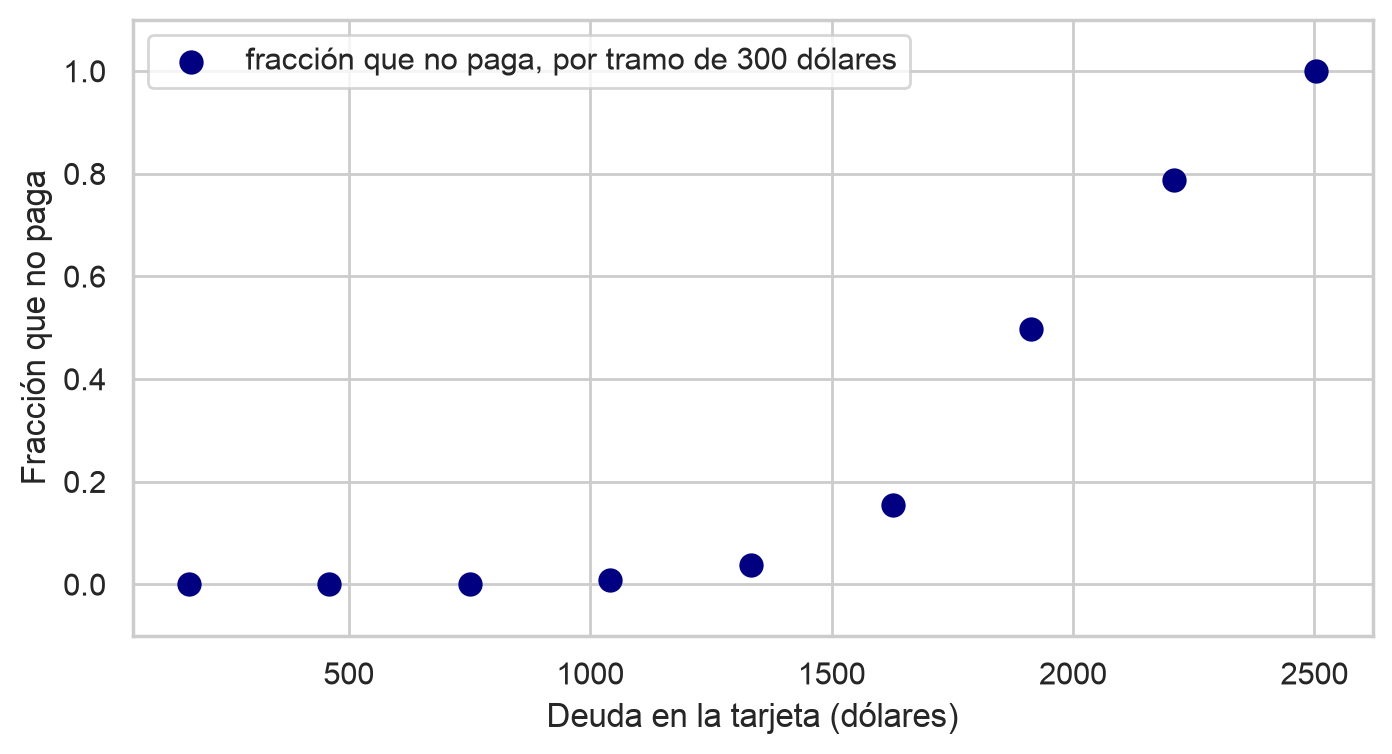

In [34]:
ok = por_tramo

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ok["Deuda"], ok["Fraccion"], s=60, color="navy", zorder=5, label="fracción que no paga, por tramo de 300 dólares")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="Fracción que no paga", ylim=(-0.1, 1.1))
ax.legend()
plt.show()

## 6. La regresión logística

**Objetivo:** entender de dónde sale la curva en S, ajustarla y leer sus coeficientes.

La idea: no inventar una curva, sino poner la recta de siempre en una escala donde no pueda salirse de rango. Se construye en tres pasos.

**1. Los odds (chances).** La probabilidad dicha de otra forma: cuántos síes hay por cada no, $P / (1 - P)$. Con $P = 0{,}8$, de cada 10 clientes 8 no pagan y 2 pagan: odds $8 / 2 = 4$, cuatro a uno. Las odds van de 0 a infinito: ya no tienen el techo de 1.

**2. El logaritmo de los odds.** Puede ser cualquier número: negativo cuando el sí es menos probable que el no, 0 cuando empatan, positivo cuando el sí es más probable. Sin techo ni piso: aquí sí cabe una recta.

In [35]:
for P in [0.2, 0.5, 0.8, 0.95]:
    odds = P / (1 - P)
    print(f"P = {P:.2f}  |  odds = {odds:.2f}  |  log de los odds = {np.log(odds):+.2f}")

P = 0.20  |  odds = 0.25  |  log de los odds = -1.39
P = 0.50  |  odds = 1.00  |  log de los odds = +0.00
P = 0.80  |  odds = 4.00  |  log de los odds = +1.39
P = 0.95  |  odds = 19.00  |  log de los odds = +2.94


**3. La recta va en la escala del logaritmo de los odds.** Con los nueve tramos de la sección 5, el logaritmo de los odds de cada tramo sigue una recta cuando se lo grafica contra la deuda (los tramos con fracción 0 o 1 quedan fuera, porque su logaritmo no existe):

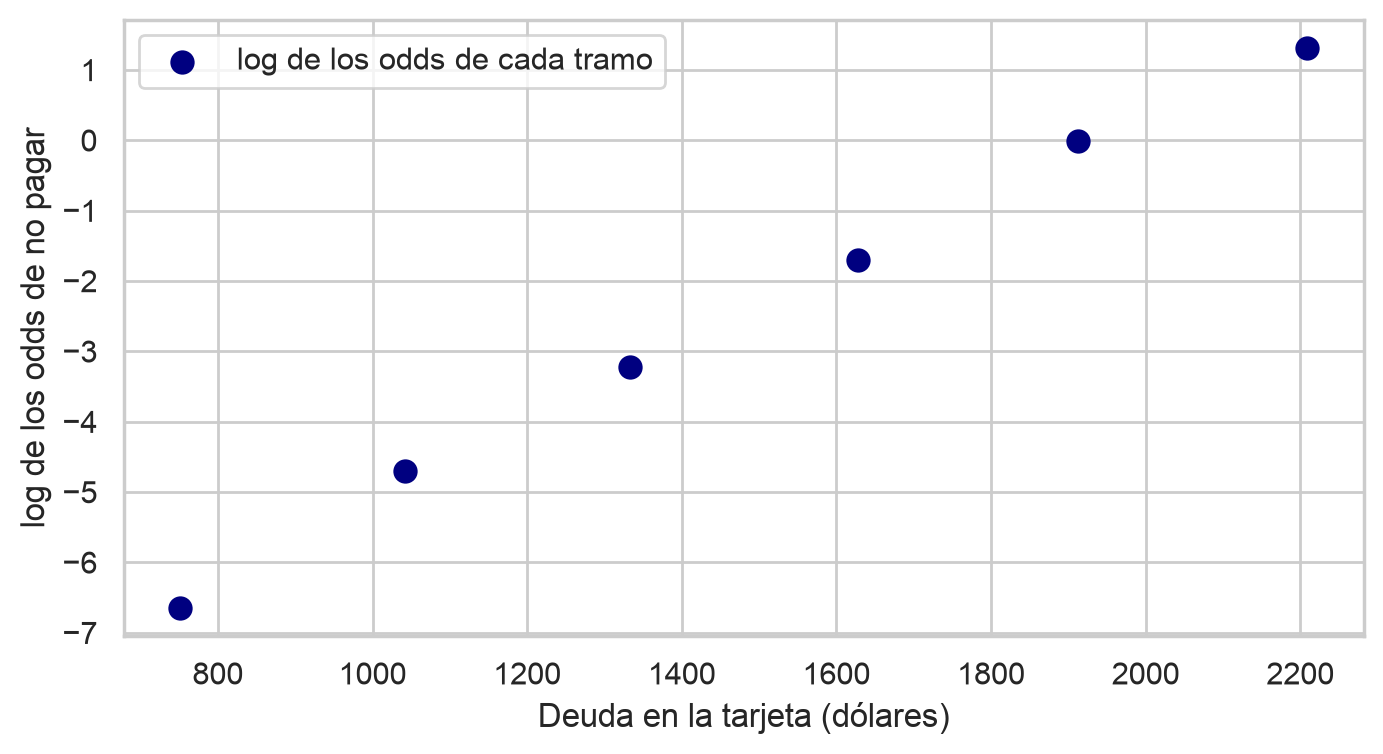

In [36]:
con_ambos = ok[(ok["Fraccion"] > 0) & (ok["Fraccion"] < 1)]
log_chances = np.log(con_ambos["Fraccion"] / (1 - con_ambos["Fraccion"]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(con_ambos["Deuda"], log_chances, s=60, color="navy", zorder=5, label="log de los odds de cada tramo")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="log de los odds de no pagar")
ax.legend()
plt.show()

Eso es lo que la **regresión logística** supone: que el logaritmo de las odds es la recta $a + b\,x$:

$$\log\frac{P}{1 - P} = a + b\,x$$

donde $P$ es la probabilidad de un sí dado $x$ y $P / (1 - P)$ son los odds. Para volver a la probabilidad se despeja $P$ en cuatro pasos, con $z = a + b\,x$:

1. $\log\frac{P}{1 - P} = z$, el modelo.
2. $\frac{P}{1 - P} = e^{z}$, se deshace el logaritmo con $e$.
3. $P = e^{z}(1 - P)$, o sea $P\,(1 + e^{z}) = e^{z}$.
4. $P = \frac{e^{z}}{1 + e^{z}} = \frac{1}{1 + e^{-z}}$, la **sigmoide**:

$$P(y = 1 \mid x) = \frac{1}{1 + e^{-(a + b\,x)}}$$

Por eso el exponente es $a + b\,x$: es la recta del modelo, que reaparece al despejar. Por muy grande o chica que sea la recta, la sigmoide queda entre 0 y 1. Y como sumar $b$ en el logaritmo es multiplicar afuera por $e^{b}$, $e^{b}$ dice cuánto se **multiplican** los odds por cada unidad de $x$, igual que en el modelo en log de la clase 04.

En statsmodels es `smf.logit`, con la misma sintaxis de fórmulas que `smf.ols`. No se ajusta por mínimos cuadrados (con un 0/1 no hay residuo que tenga sentido) sino por **máxima verosimilitud**: se buscan los $a$ y $b$ que hacen más probable haber observado exactamente estos síes y noes, por iteraciones.

In [37]:
logistica = smf.logit("no_paga ~ deuda_100", data=clientes).fit()
a, b = logistica.params


Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


In [38]:
print(f"\na = {a:.2f}, b = {b:.3f} por cada 100 dólares de deuda")
print(f"e^b = {np.exp(b):.2f}: cada 100 dólares más de deuda multiplican los odds de no pagar por {np.exp(b):.1f}")


a = -10.65, b = 0.550 por cada 100 dólares de deuda
e^b = 1.73: cada 100 dólares más de deuda multiplican los odds de no pagar por 1.7


La salida del ajuste muestra las iteraciones (`Optimization terminated successfully`): es la máxima verosimilitud trabajando. La curva, y qué probabilidad da para distintos deudas:

In [39]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

for deuda in [500, 1000, 1500, 2000, 2500]:
    print(f"deuda {deuda:>5} dólares: P(no paga) = {sigmoide(a + b * deuda / 100):.3f}")
print(f"la curva cruza 0,5 en {-a / b * 100:.0f} dólares")

deuda   500 dólares: P(no paga) = 0.000
deuda  1000 dólares: P(no paga) = 0.006
deuda  1500 dólares: P(no paga) = 0.083
deuda  2000 dólares: P(no paga) = 0.586
deuda  2500 dólares: P(no paga) = 0.957
la curva cruza 0,5 en 1937 dólares


In [40]:
# lo mismo con predict: recibe una tabla con la columna del modelo y devuelve probabilidades
nuevos = pd.DataFrame({"deuda_100": [5, 10, 15, 20, 25]})
nuevos["P_no_paga"] = logistica.predict(nuevos)
nuevos

,deuda_100,P_no_paga
0,5,0.000
1,10,0.006
2,15,0.083
3,20,0.586
4,25,0.957


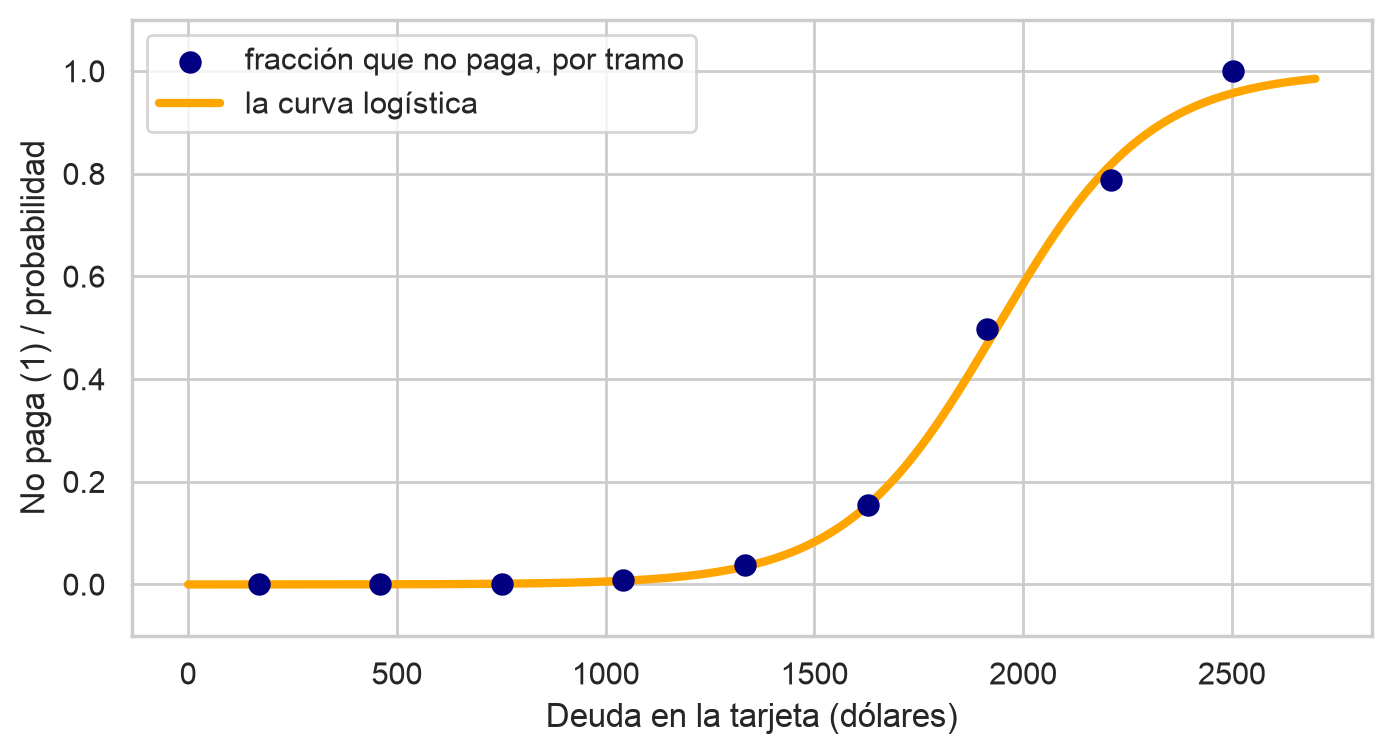

In [41]:
grilla = np.linspace(0, 2700, 200)   # deudas de 0 a 2.700 dólares
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ok["Deuda"], ok["Fraccion"], s=50, color="navy", zorder=5, label="fracción que no paga, por tramo")
ax.plot(grilla, sigmoide(a + b * grilla / 100), color="orange", lw=3, label="la curva logística")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="No paga (1) / probabilidad", ylim=(-0.1, 1.1))
ax.legend()
plt.show()

La curva pasa por las fracciones de cada tramo: es la S que la recta de la clase 04 no puede dibujar, porque una recta se sale de 0 y 1.

### El mismo summary

Las columnas son las de la primera parte: **coef**, **std err**, **z**, **P>|z|** y el intervalo. La única diferencia es $z$ en lugar de $t$: con 10.000 clientes la referencia es la normal en vez de la t de Student, y $P>|z|$ se lee igual que $P>|t|$.

In [42]:
logistica.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.6513,0.361,-29.491,0.000,-11.359,-9.943
deuda_100,0.5499,0.022,24.952,0.000,0.507,0.593


El intervalo de $b$ también se puede pasar a odds con `np.exp`: el multiplicador por cada 100 dólares está entre 1,66 y 1,81.

In [43]:
intervalo = logistica.conf_int().loc["deuda_100"]
intervalo

0   0.507
1   0.593
Name: deuda_100, dtype: float64

In [44]:
print(f"b entre {intervalo.iloc[0]:.3f} y {intervalo.iloc[1]:.3f}")
print(f"e^b entre {np.exp(intervalo.iloc[0]):.2f} y {np.exp(intervalo.iloc[1]):.2f}")

b entre 0.507 y 0.593
e^b entre 1.66 y 1.81


### ¿Y el R²?

El R² de la clase 04 era la fracción de la varianza de $y$ que la recta explica, y salía de los residuos al cuadrado. En la logística no hay residuos al cuadrado con sentido: la respuesta es 0 o 1 y el ajuste es por máxima verosimilitud. Lo que statsmodels muestra en la cabecera del summary (la tabla `tables[0]`, que hasta ahora no mirábamos) es un **pseudo R²** de McFadden: compara la verosimilitud del modelo con la de un modelo sin variables, que predice la misma $p$ para todos.

In [45]:
logistica.summary().tables[0]

Dep. Variable:,no_paga,No. Observations:,10000
Model:,Logit,Df Residuals:,9998
Method:,MLE,Df Model:,1
Date:,"Fri, 02 Oct 2026",Pseudo R-squ.:,0.4534
Time:,14:18:08,Log-Likelihood:,-798.23
converged:,True,LL-Null:,-1460.3
Covariance Type:,nonrobust,LLR p-value:,6.233e-290


In [46]:
print(f"pseudo R² (McFadden): {logistica.prsquared:.3f}")

pseudo R² (McFadden): 0.453


No se lee como el R² de la recta: no es una fracción de varianza explicada, y sus valores son más bajos (entre 0,2 y 0,4 ya se considera un modelo útil). Sirve para comparar modelos ajustados a los mismos datos, no para decir "explica el 45%". Para un clasificador, la medida natural es otra, y viene en la sección 9: cuántas veces acierta y en qué se equivoca.

## 7. Varias variables

**Objetivo:** agregar variables, numéricas y dummies, y entender por qué un coeficiente cambia cuando entran otras.

Partimos de una pregunta simple: ¿los estudiantes pagan peor que el resto? Los datos, otra vez:

In [47]:
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles,tramo
0,No,No,729.526,44361.625,0,0,7.295,44.362,"(600, 900]"
1,No,Yes,817.180,12106.135,0,1,8.172,12.106,"(600, 900]"
2,No,No,1073.549,31767.139,0,0,10.735,31.767,"(900, 1200]"
3,No,No,529.251,35704.494,0,0,5.293,35.704,"(300, 600]"
4,No,No,785.656,38463.496,0,0,7.857,38.463,"(600, 900]"


In [48]:
print(clientes.groupby("student")["no_paga"].mean().rename("fracción que no paga"))


student
No    0.029
Yes   0.043
Name: fracción que no paga, dtype: float64


Parece que sí: 4,3% de los estudiantes deja de pagar, contra 2,9% del resto. Un modelo con solo la variable `estudiante` (una dummy, como el modo de transporte de la clase 04) ve exactamente esa diferencia:

In [49]:
solo_estudiante = smf.logit("no_paga ~ estudiante", data=clientes).fit(disp=0)
print(f"\nsolo estudiante: b = {solo_estudiante.params['estudiante']:.3f}, e^b = {np.exp(solo_estudiante.params['estudiante']):.2f}")


solo estudiante: b = 0.405, e^b = 1.50


b positivo, e^b = 1,5: según este modelo, ser estudiante sube los odds de no pagar. Antes de creerlo hay que mirar qué más distingue a los estudiantes. Miremos la deuda:

In [50]:
print(clientes.groupby("student")["balance"].mean().rename("deuda media"))

student
No    771.770
Yes   987.818
Name: deuda media, dtype: float64


In [51]:
alta = clientes["balance"] > 1500   # True para los clientes con deuda alta
print(clientes.groupby("student")["balance"].apply(lambda s: (s > 1500).mean()).rename("fracción del grupo con deuda sobre 1.500 dólares"))

student
No    0.069
Yes   0.144
Name: fracción del grupo con deuda sobre 1.500 dólares, dtype: float64


Entonces la comparación del total mezcla dos cosas: ser estudiante y tener más deuda. La comparación justa es dentro de cada tramo de deuda: estudiantes y no estudiantes que deben lo mismo.

In [52]:
# La fracción que no paga en cada tramo de deuda, estudiantes y no estudiantes por separado
por_tramo_est = clientes.groupby(["tramo", "student"], observed=True)["no_paga"].mean().unstack()
por_tramo_est.columns = ["no estudiantes", "estudiantes"]
por_tramo_est

,no estudiantes,estudiantes
tramo,,
"(0, 300]",0.000,0.000
"(300, 600]",0.000,0.000
"(600, 900]",0.002,0.000
"(900, 1200]",0.011,0.004
"(1200, 1500]",0.044,0.030
"(1500, 1800]",0.183,0.114
"(1800, 2100]",0.627,0.378
"(2100, 2400]",0.867,0.757
"(2400, 2700]",1.000,1.000


En cada tramo donde hay clientes de los dos tipos, los estudiantes dejan de pagar **menos** que los no estudiantes. ¿Cómo puede ser que en el total sean peores? Con un ejemplo inventado de 200 clientes se ve el mecanismo:

| | no estudiantes | estudiantes |
|---|---|---|
| deuda baja | 80 clientes, 4 no pagan (5%) | 20 clientes, 0 no pagan (0%) |
| deuda alta | 20 clientes, 10 no pagan (50%) | 80 clientes, 32 no pagan (40%) |
| **total** | **100 clientes, 14 no pagan (14%)** | **100 clientes, 32 no pagan (32%)** |

Dentro de cada tramo los estudiantes pagan mejor (0% contra 5%, 40% contra 50%). Pero 80 de los 100 estudiantes están en el tramo de deuda alta, donde casi todos pagan mal, y solo 20 de los 100 no estudiantes. El total no compara estudiantes con no estudiantes: compara un grupo endeudado con uno que no lo está.

Los dos modelos hacen esas dos lecturas. El de solo `estudiante` mira el total. El que incluye la deuda compara clientes con la misma deuda, porque cada coeficiente se lee a igualdad de las otras variables:

In [53]:
multiple = smf.logit("no_paga ~ deuda_100 + estudiante", data=clientes).fit(disp=0)
multiple.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.7495,0.369,-29.115,0.000,-11.473,-10.026
deuda_100,0.5738,0.023,24.748,0.000,0.528,0.619
estudiante,-0.7149,0.148,-4.846,0.000,-1.004,-0.426


El coeficiente de `estudiante` en los dos modelos, lado a lado:

In [54]:
comparacion = pd.DataFrame({
    "solo estudiante": [solo_estudiante.params["estudiante"], np.exp(solo_estudiante.params["estudiante"])],
    "con la deuda en el modelo": [multiple.params["estudiante"], np.exp(multiple.params["estudiante"])],
}, index=["b de estudiante", "e^b (multiplicador de los odds)"])
comparacion

,solo estudiante,con la deuda en el modelo
b de estudiante,0.405,-0.715
e^b (multiplicador de los odds),1.499,0.489


El coeficiente de estudiante cambió de signo: de +0,40 a −0,72. A igual deuda, los odds de un estudiante son la **mitad** (e^b = 0,49). Ninguno de los dos modelos se equivoca en la aritmética: responden preguntas distintas, y la segunda es la que interesa, porque la primera le atribuye al estudiante algo que en realidad hace la deuda. Es la confusión de variables de la clase 04, ahora en la logística.

¿Y el ingreso? Es la tercera variable de la tabla; entra ahora, como un paso aparte:

In [55]:
con_ingreso = smf.logit("no_paga ~ deuda_100 + estudiante + ingreso_miles", data=clientes).fit(disp=0)
con_ingreso.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.8690,0.492,-22.079,0.000,-11.834,-9.904
deuda_100,0.5737,0.023,24.737,0.000,0.528,0.619
estudiante,-0.6468,0.236,-2.738,0.006,-1.110,-0.184
ingreso_miles,0.0030,0.008,0.370,0.712,-0.013,0.019


El ingreso no aporta nada: su coeficiente es 0,003 por cada mil dólares, con p = 0,71, y los otros dos coeficientes cambian poco (estudiante pasa de −0,72 a −0,65; sigue negativo y con p = 0,006). Con la deuda ya en el modelo, saber el ingreso no dice nada nuevo sobre el no pago. Los e^b de las tres variables:

In [56]:
np.exp(con_ingreso.params).rename("e^b: multiplicador de los odds")

Intercept       0.000
deuda_100       1.775
estudiante      0.524
ingreso_miles   1.003
Name: e^b: multiplicador de los odds, dtype: float64

El pseudo R² dice lo mismo: casi no cambia al agregar el ingreso.

In [57]:
for nombre, modelo in [("solo deuda", logistica), ("deuda + estudiante", multiple), ("deuda + estudiante + ingreso", con_ingreso)]:
    print(f"{nombre:28s} pseudo R² = {modelo.prsquared:.3f}")

solo deuda                   pseudo R² = 0.453
deuda + estudiante           pseudo R² = 0.462
deuda + estudiante + ingreso pseudo R² = 0.462


### El modelo final, escrito

Con los coeficientes del summary, el modelo de los clientes queda:

$$\log\frac{P}{1 - P} = a + b_1 \cdot \text{deuda}_{100} + b_2 \cdot \text{estudiante} + b_3 \cdot \text{ingreso}_{miles}$$

$$P(\text{no paga}) = \frac{1}{1 + e^{-(a + b_1 \cdot \text{deuda}_{100} + b_2 \cdot \text{estudiante} + b_3 \cdot \text{ingreso}_{miles})}}$$

donde `estudiante` vale 1 o 0. Con los números:

In [58]:
a, b1, b2, b3 = con_ingreso.params[["Intercept", "deuda_100", "estudiante", "ingreso_miles"]]
print(f"log(P / (1 - P)) = {a:.2f} + {b1:.2f} · deuda_100 {b2:+.2f} · estudiante {b3:+.4f} · ingreso_miles")

log(P / (1 - P)) = -10.87 + 0.57 · deuda_100 -0.65 · estudiante +0.0030 · ingreso_miles


Para usarlo con un cliente concreto se reemplazan sus valores en la recta y se pasa el resultado por la sigmoide. Un estudiante con 2.000 dólares de deuda y 20 mil dólares de ingreso anual:

In [59]:
z = a + b1 * 20 + b2 * 1 + b3 * 20   # deuda_100 = 20, estudiante = 1, ingreso_miles = 20
print(f"la recta: z = {z:.2f}")
print(f"la probabilidad: P = 1 / (1 + e^(-z)) = {1 / (1 + np.exp(-z)):.3f}")
print(f"con predict: {con_ingreso.predict(pd.DataFrame({"deuda_100": [20], "estudiante": [1], "ingreso_miles": [20]})).iloc[0]:.3f}")

la recta: z = 0.02
la probabilidad: P = 1 / (1 + e^(-z)) = 0.504
con predict: 0.504


## 8. Otro problema

Hasta aquí, un solo problema y una sola dummy. Un segundo problema sirve para ver el mismo modelo con más variables: dos categóricas, el sexo y la clase del pasaje (que tiene tres categorías, no dos), y una numérica, la edad. Además, aquí el sí es frecuente, y eso va a importar al clasificar.

Los datos: 891 pasajeros del Titanic, del repositorio de datos de ejemplo de seaborn. La respuesta es si sobrevivieron; las variables, el sexo, la clase del pasaje (1, 2 o 3) y la edad, que falta en 177 pasajeros: el modelo usa los 714 con edad conocida.

In [60]:
pasajeros = pd.read_csv(BASE + "titanic.csv")
pasajeros["sobrevivio"] = pasajeros["survived"]
pasajeros["sexo"] = pasajeros["sex"].map({"female": "mujer", "male": "hombre"})
pasajeros["clase"] = pasajeros["pclass"]
pasajeros["edad"] = pasajeros["age"]
pasajeros.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sobrevivio,sexo,clase,edad
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False,0,hombre,3,22.000
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False,1,mujer,1,38.000
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True,1,mujer,3,26.000
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False,1,mujer,1,35.000
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True,0,hombre,3,35.000


In [61]:
print("pasajeros:", len(pasajeros), "| sobrevivió:", round(pasajeros["sobrevivio"].mean(), 3), "| sin edad:", pasajeros["edad"].isna().sum())


pasajeros: 891 | sobrevivió: 0.384 | sin edad: 177


In [62]:
pasajeros.groupby(["clase", "sexo"])["sobrevivio"].mean().unstack()

sexo,hombre,mujer
clase,,
1,0.369,0.968
2,0.157,0.921
3,0.135,0.500


La clase es categórica aunque sea un número: `C(clase)` le dice a statsmodels que cree las dummies (segunda y tercera clase, con la primera como referencia). El sexo es texto, así que la dummy se crea sola, con `hombre` como referencia por orden alfabético.

In [63]:
con_edad = pasajeros.dropna(subset=["edad"])
titanic = smf.logit("sobrevivio ~ C(sexo) + C(clase) + edad", data=con_edad).fit(disp=0)
titanic.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,1.2542,0.360,3.485,0.000,0.549,1.960
C(sexo)[T.mujer],2.5228,0.207,12.164,0.000,2.116,2.929
C(clase)[T.2],-1.3098,0.278,-4.710,0.000,-1.855,-0.765
C(clase)[T.3],-2.5806,0.281,-9.169,0.000,-3.132,-2.029
edad,-0.0370,0.008,-4.831,0.000,-0.052,-0.022


In [64]:
np.exp(titanic.params).rename("e^b: multiplicador de los odds")

Intercept           3.505
C(sexo)[T.mujer]   12.463
C(clase)[T.2]       0.270
C(clase)[T.3]       0.076
edad                0.964
Name: e^b: multiplicador de los odds, dtype: float64

### El modelo del Titanic, escrito

Las categóricas entran como dummies: `mujer` vale 1 para las mujeres y 0 para los hombres (la referencia); `clase2` y `clase3` valen 1 en segunda y tercera clase, y las dos valen 0 en primera (la referencia):

$$\log\frac{P}{1 - P} = a + b_1 \cdot \text{mujer} + b_2 \cdot \text{clase2} + b_3 \cdot \text{clase3} + b_4 \cdot \text{edad}$$

Con los números:

In [65]:
a, b1, b2, b3, b4 = titanic.params
print(f"log(P / (1 - P)) = {a:.2f} {b1:+.2f} · mujer {b2:+.2f} · clase2 {b3:+.2f} · clase3 {b4:+.3f} · edad")

log(P / (1 - P)) = 1.25 +2.52 · mujer -1.31 · clase2 -2.58 · clase3 -0.037 · edad


Una mujer de primera clase de 30 años: mujer = 1, clase2 = 0, clase3 = 0, edad = 30. Un hombre de tercera de 30 años: mujer = 0, clase3 = 1.

In [66]:
for nombre, mujer, clase2, clase3, edad in [("mujer, primera, 30 años", 1, 0, 0, 30), ("hombre, tercera, 30 años", 0, 0, 1, 30)]:
    z = a + b1 * mujer + b2 * clase2 + b3 * clase3 + b4 * edad
    print(f"{nombre}: z = {z:+.2f}  ->  P = {1 / (1 + np.exp(-z)):.3f}")

mujer, primera, 30 años: z = +2.67  ->  P = 0.935
hombre, tercera, 30 años: z = -2.44  ->  P = 0.080


Cada e^b compara con su referencia, a igualdad de las otras variables: los odds de sobrevivir de una mujer son 12 veces las de un hombre; las de la tercera clase, el 8% de las de la primera; y cada año de edad las multiplica por 0,96. Con varias variables, `predict` suma los aportes en la recta y la sigmoide entrega la probabilidad:

In [67]:
perfiles = pd.DataFrame({
    "sexo": ["mujer", "mujer", "hombre", "hombre"],
    "clase": [1, 3, 1, 3],
    "edad": [30, 30, 30, 30],
})
perfiles["P_sobrevive"] = titanic.predict(perfiles)
perfiles

,sexo,clase,edad,P_sobrevive
0,mujer,1,30,0.935
1,mujer,3,30,0.522
2,hombre,1,30,0.536
3,hombre,3,30,0.080


## 9. Clasificar: de la probabilidad a la decisión

**Objetivo:** convertir la probabilidad en un sí o no, y medir los dos errores.

El modelo entrega probabilidades. Para decidir hace falta un **umbral**: el más simple es 0,5. La tabla de lo real contra lo predicho es la **matriz de confusión**, y tiene cuatro celdas con nombre:

| | predicho sí | predicho no |
|---|---|---|
| **real sí** | verdadero positivo (VP) | **falso negativo (FN)** |
| **real no** | **falso positivo (FP)** | verdadero negativo (VN) |

Un **falso negativo** es un sí que el modelo declaró no: un cliente que no pagará y recibió la tarjeta. Un **falso positivo** es un no declarado sí: un cliente que sí pagaba y a quien se le negó. No cuestan lo mismo, y cuál cuesta más lo dice el problema, no el modelo.

In [68]:
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles,tramo
0,No,No,729.526,44361.625,0,0,7.295,44.362,"(600, 900]"
1,No,Yes,817.180,12106.135,0,1,8.172,12.106,"(600, 900]"
2,No,No,1073.549,31767.139,0,0,10.735,31.767,"(900, 1200]"
3,No,No,529.251,35704.494,0,0,5.293,35.704,"(300, 600]"
4,No,No,785.656,38463.496,0,0,7.857,38.463,"(600, 900]"


In [69]:
clientes["prob"] = logistica.predict(clientes)
clientes["prediccion"] = (clientes["prob"] >= 0.5).astype(int)
clientes[["balance", "no_paga", "prob", "prediccion"]].head(10)

,balance,no_paga,prob,prediccion
0,729.526,0,0.001,0
1,817.180,0,0.002,0
2,1073.549,0,0.009,0
3,529.251,0,0.000,0
4,785.656,0,0.002,0
5,919.589,0,0.004,0
6,825.513,0,0.002,0
7,808.668,0,0.002,0
8,1161.058,0,0.014,0
9,0.000,0,0.000,0


In [70]:
# La matriz de confusión: crosstab de lo real contra lo predicho
pd.crosstab(clientes["no_paga"], clientes["prediccion"], rownames=["real"], colnames=["predicho"])

predicho,0,1
real,,
0,9625,42
1,233,100


De los 333 clientes que no pagan, el modelo detecta 100 y se le escapan 233 (falsos negativos); a 42 clientes que sí pagan los declara morosos (falsos positivos). ¿Y la **exactitud**, la fracción de aciertos?

In [71]:
exactitud = (clientes["prediccion"] == clientes["no_paga"]).mean()
exactitud

np.float64(0.9725)

In [72]:

base = 1 - clientes["no_paga"].mean()   # decir siempre "paga", la clase mayoritaria
base

np.float64(0.9667)

In [73]:
print(f"exactitud del modelo: {exactitud:.4f}")
print(f"decir siempre \"paga\": {base:.4f}")

exactitud del modelo: 0.9725
decir siempre "paga": 0.9667


97,3% contra 96,7%: casi lo mismo que no tener modelo. Cuando el sí es raro (3,3%), la exactitud mide sobre todo lo fácil, los noes. Hay que contar los dos errores por separado: 233 falsos negativos (7 de cada 10 clientes que no pagan se le escapan al modelo) y 42 falsos positivos. Si al banco le cuesta más el falso negativo, convendría bajar el umbral y aceptar más falsos positivos; cómo elegir el umbral según el costo de cada error, y las medidas que resumen los dos errores (sensibilidad y especificidad), quedan para la próxima clase.

### El Titanic como clasificador

Con un sí frecuente (41% sobrevivió), la exactitud sí informa:

In [74]:
con_edad = con_edad.copy()
con_edad["prob"] = titanic.predict(con_edad)
con_edad["prediccion"] = (con_edad["prob"] >= 0.5).astype(int)
con_edad[["sexo", "clase", "edad", "sobrevivio", "prob", "prediccion"]].head(10)

,sexo,clase,edad,sobrevivio,prob,prediccion
0,hombre,3,22.000,0,0.105,0
1,mujer,1,38.000,1,0.915,1
2,mujer,3,26.000,1,0.558,1
3,mujer,1,35.000,1,0.923,1
4,hombre,3,35.000,0,0.068,0
6,hombre,1,54.000,0,0.322,0
7,hombre,3,2.000,0,0.198,0
8,mujer,3,27.000,1,0.549,1
9,mujer,2,14.000,1,0.875,1
10,mujer,3,4.000,1,0.740,1


In [75]:
pd.crosstab(con_edad["sobrevivio"], con_edad["prediccion"], rownames=["real"], colnames=["predicho"])


predicho,0,1
real,,
0,356,68
1,83,207


In [76]:
print(f"\nexactitud del modelo: {(con_edad['prediccion'] == con_edad['sobrevivio']).mean():.3f}")
print(f"decir siempre \"murió\": {1 - con_edad['sobrevivio'].mean():.3f}")


exactitud del modelo: 0.789
decir siempre "murió": 0.594


79% de aciertos contra el 59% de decir que todos murieron: el modelo aporta 20 puntos. Los errores: 83 falsos negativos, pasajeros que sobrevivieron y el modelo daba por muertos (hombres jóvenes de tercera clase), y 68 falsos positivos.

## 10. Evaluar fuera de la muestra

**Objetivo:** medir el modelo en datos que no usó para ajustarse.

Todas las exactitudes anteriores se midieron en los mismos datos con que se ajustó el modelo, y eso es hacer trampa: el modelo ya los vio. La medida honesta se toma en una parte de **prueba** separada al azar antes de ajustar; la otra parte, de **entrenamiento**, es la única que ve el modelo. Son seis pasos:

1. Un generador de números al azar, con semilla.
2. Sortear qué filas van a entrenamiento.
3. Separar las dos tablas.
4. Ajustar el modelo solo con la de entrenamiento.
5. Medir la exactitud en entrenamiento.
6. Medir la exactitud en prueba, la que vale.

**Paso 1.** Un generador de números al azar con semilla para que el reparto sea el mismo cada vez que se corra el notebook:

In [77]:
rng = np.random.default_rng(7)
rng

Generator(PCG64) at 0x1179B17E0

**Paso 2.** `rng.random` da un número entre 0 y 1 por cada fila. Las filas que sacan menos de 0,7 van a entrenamiento: en promedio, el 70%. El resultado es una columna de `True` y `False`, una por pasajero:

In [78]:
en_entrenamiento = rng.random(len(con_edad)) < 0.7   # True para el 70% de las filas, al azar
en_entrenamiento

array([ True, False, False,  True,  True, False,  True, False, False,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True, False,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True, False,  True, False,  True,
       False,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True, False,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True,  True, False, False, False,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True, False, False,  True, False,  True, False, False,
        True,  True, False,  True,  True, False,  True, False,  True,
        True,  True,

**Paso 3.** Con esa columna se separan las dos tablas: `entrenamiento` con las filas `True`, y `prueba` con las `False` (el `~` invierte la columna):

In [79]:
entrenamiento = con_edad[en_entrenamiento]
prueba = con_edad[~en_entrenamiento]
print(f"entrenamiento: {len(entrenamiento)} pasajeros | prueba: {len(prueba)}")



entrenamiento: 496 pasajeros | prueba: 218


**Paso 4.** Se ajusta el modelo solo con la tabla de entrenamiento. La de prueba no participa: el modelo no la ve.

In [80]:
modelo_e = smf.logit("sobrevivio ~ sexo + C(clase) + edad", data=entrenamiento).fit(disp=0)
modelo_e.params.round(3)

Intercept        1.181
sexo[T.mujer]    2.409
C(clase)[T.2]   -1.257
C(clase)[T.3]   -2.513
edad            -0.036
dtype: float64

**Paso 5.** La exactitud en entrenamiento, con los pasos de la sección 9: `predict` da las probabilidades, el umbral 0,5 las convierte en predicciones, y se cuenta qué fracción coincide con la respuesta real:

In [81]:
prob_e = modelo_e.predict(entrenamiento)            # probabilidades para las filas de entrenamiento
prediccion_e = (prob_e >= 0.5).astype(int)          # umbral 0,5
exactitud_e = (prediccion_e == entrenamiento["sobrevivio"]).mean()
print(f"exactitud en entrenamiento: {exactitud_e:.3f}   ({len(entrenamiento)} pasajeros que el modelo sí vio)")

exactitud en entrenamiento: 0.778   (496 pasajeros que el modelo sí vio)


**Paso 6.** Lo mismo, con el mismo modelo, sobre la tabla de prueba: pasajeros que el modelo nunca vio. Esta es la cifra que vale.

In [82]:
prob_p = modelo_e.predict(prueba)                   # el mismo modelo, aplicado a filas que nunca vio
prediccion_p = (prob_p >= 0.5).astype(int)
exactitud_p = (prediccion_p == prueba["sobrevivio"]).mean()
print(f"exactitud en prueba: {exactitud_p:.3f}   ({len(prueba)} pasajeros que el modelo no vio)")

exactitud en prueba: 0.830   (218 pasajeros que el modelo no vio)


Con un modelo simple como este las dos cifras se parecen, y que la de prueba salga un poco más alta o más baja es cosa del azar del reparto: buena señal, el modelo no aprendió el azar de su muestra. Con modelos más flexibles la exactitud de entrenamiento sube y la de prueba no, y la de prueba es la única que vale. Este es el punto de partida de la evaluación de modelos que sigue en la unidad 6 del curso.

---

**Próxima clase (martes 15-sep):** sensibilidad y especificidad, cómo elegir el umbral según el costo de cada error y la curva ROC; después, regresión regularizada, Ridge y Lasso. Recuerde: el primer análisis exploratorio se entrega el martes 15 de septiembre.